In [20]:
from sklearn.datasets import load_diabetes
diabetes=load_diabetes()

In [21]:
X = diabetes.data
y = diabetes.target

In [22]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=7)

In [23]:
print(X_train.shape)

(353, 10)


In [24]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

model = Sequential([    #X_train의 10개 열 지정
    Input(shape=(X_train.shape[1],)),
    Dense(24, activation='relu'),
    Dense(12, activation='relu'),
    Dense(6, activation='relu'),
    Dense(1)
])
model.compile(
    loss='mse',
    optimizer='adam',
    metrics=['mse', 'mae']
)
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 24)             │           264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 12)             │           300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 6)              │            78 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │             7 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 649 (2.54 KB)

 Trainable params: 649 (2.54 KB)

 Non-trainable params: 0 (0.00 B)

<Axes: >

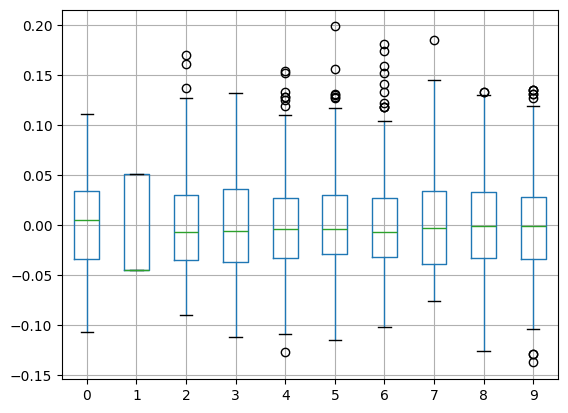

In [25]:
import pandas as pd
pd.DataFrame(X_train).boxplot()

In [26]:
from tensorflow.keras.callbacks import EarlyStopping
early_stopping = EarlyStopping(monitor='val_loss', patience=50)
hist = model.fit(X_train, y_train, epochs=500, validation_split=0.2, callbacks=[early_stopping])
                                                #train데이터 중 validation비율 20%

Epoch 1/500
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 30440.5645 - mae: 155.2051 - mse: 30440.5645 - val_loss: 27687.7148 - val_mae: 149.5519 - val_mse: 27687.7148
Epoch 2/500
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 30420.8828 - mae: 155.1422 - mse: 30420.8828 - val_loss: 27665.9551 - val_mae: 149.4811 - val_mse: 27665.9551
Epoch 3/500
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 30395.4121 - mae: 155.0641 - mse: 30395.4121 - val_loss: 27639.4980 - val_mae: 149.3951 - val_mse: 27639.4980
Epoch 4/500
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 30365.5293 - mae: 154.9697 - mse: 30365.5293 - val_loss: 27606.8516 - val_mae: 149.2884 - val_mse: 27606.8516
Epoch 5/500
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 30327.1562 - mae: 154.8520 - mse: 30327.1562 - val_loss: 27566.4551 - val_mae: 149.1561 - val_mse: 27566.4551
Epoch 6/500
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 30279.9512 - mae: 154.7037 - mse: 30279.9512 - val_loss: 27514.9336 - val_mae: 148.9873 - val_mse: 27514.93

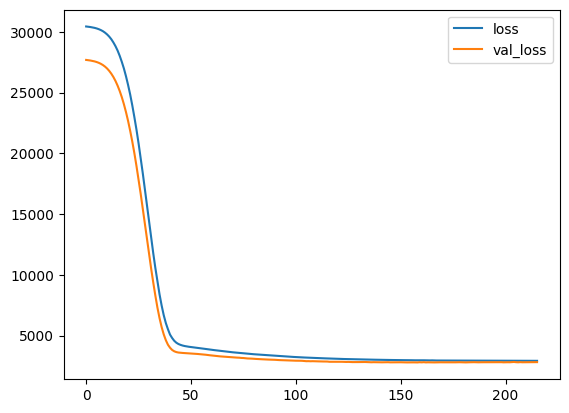

In [27]:
import matplotlib.pyplot as plt
plt.plot(hist.history['loss'])
plt.plot(hist.history['val_loss'])
plt.legend(['loss', 'val_loss'])
plt.show()

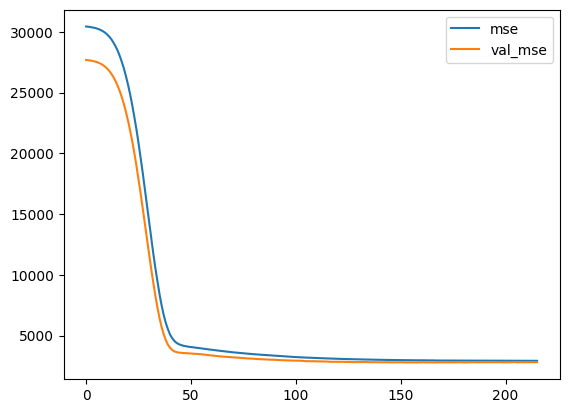

In [28]:
import matplotlib.pyplot as plt
plt.plot(hist.history['mse'])
plt.plot(hist.history['val_mse'])
plt.legend(['mse', 'val_mse'])
plt.show()

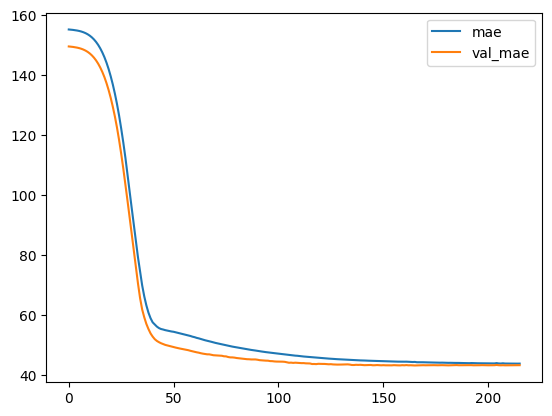

In [29]:
import matplotlib.pyplot as plt
plt.plot(hist.history['mae'])
plt.plot(hist.history['val_mae'])
plt.legend(['mae', 'val_mae'])
plt.show()

In [30]:
scores=model.evaluate(X_train, y_train)
print(scores)

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 2894.0869 - mae: 43.7966 - mse: 2894.0869 
[2894.0869140625, 2894.0869140625, 43.796566009521484]


In [31]:
scores=model.evaluate(X_test, y_test)
print(scores)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2990.4016 - mae: 42.6184 - mse: 2990.4016 
[2990.401611328125, 2990.401611328125, 42.618350982666016]


In [32]:
from sklearn.metrics import r2_score
pred=model.predict(X_test)
r2_score(y_test,pred)
#설명력 40%

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 


0.39940914675913763